In [89]:
from google import genai
from google.genai import types
import pathlib
import httpx

client = genai.Client()

# Retrieve and encode the PDF byte
file_path = pathlib.Path("data/RAG_25-42.pdf")

# Upload the PDF using the File API
sample_file = client.files.upload(
    file=file_path,
)

prompt = """pdf파일에서 텍스트 내용을 추출해줘. pdf에는 다양한 텍스트와 이미지, 차트가 포함되어 있어.
            텍스트만 추출해줘.
        """

response = client.models.generate_content(
    model="gemini-2.5-flash", contents=[sample_file, prompt]
)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


다음은 제공된 PDF 파일에서 추출된 텍스트 내용입니다.

---

**CHAPTER 01 RAG 이해하기**

**학습 목표**
RAG(Retrieval-Augmented Generation)는 문서 로드, 검색, 답변 생성의 투명한 과정을 통 해 할루시네이션 현상을 줄이고, 최신 정보와 신뢰할 수 있는 외부 데이터를 활용해 응답 정확도 를 대폭 향상시킴으로써 GPT 모델의 한계를 극복하기 위한 기술입니다. RAG는 프롬프트 엔지니 어링이나 파인 튜닝보다 구현이 용이하여 실용적이며, 사용자가 원하는 대로 데이터베이스와 모 델을 커스터마이즈할 수 있어 특정 도메인에 특화된 챗봇을 제작할 수 있는 강력한 도구입니다. 그러한 RAG를 사용해야 하는 이유에 관해 알아보겠습니다.

**01 RAG를 사용해야 하는 이유**
ChatGPT는 2022년 11월 등장하자마자 순식간에 많은 사용자를 확보했습니다. 2023년 11월 에는 GPTs 스토어가 출시되어 GPT의 기능을 플러그인으로 제작하고 배포할 수 있게 되었고, 여러 고급 기능이 보완되면서 사용자들은 단순히 질문하고 답변받는 것에서 더 나아가 전문적 인 영역까지 ChatGPT를 적극적으로 활용하기 시작했습니다. 이러한 과정에서 점차 다음과 같 은 문제점들이 드러나기 시작했습니다.
1. ChatGPT는 최신 정보가 학습되어 있지 않습니다.
2. 개인이나 회사의 내부 데이터가 학습되어 있지 않아, 특정 도메인(개인 정보, 회사 내부 정보)에 대한 질문에 는 기대하는 답변을 얻을 수 없습니다.
3. ChatGPT에 개인이나 회사 정보를 담은 문서를 업로드하면 보안상 문제가 될 수 있습니다.
4. 문서의 양이 많아질수록 할루시네이션 현상이 발생하기 쉽습니다.

**ChatGPT의 한계를 보완하기 위해 주목받은 RAG**
RAG는 ChatGPT의 한계를 보완하기 위해 주목받기 시작한 기술입니다. RAG란 Retrieval- Augmented Generation의 줄임말로, 검색(Retrieval), 증강(Augmented)

In [88]:
print(response.text)

```json
[{"box_2d": [346, 252, 492, 818], "label": "chart"}, {"box_2d": [662, 252, 809, 816], "label": "chart"}]
```


### 차트를 이미지로 가져오기 위한 과정

In [3]:
!pip install supervision

  Using cached supervision-0.26.1-py3-none-any.whl.metadata (13 kB)
Using cached supervision-0.26.1-py3-none-any.whl (207 kB)


### 한글 프롬프트로 테스트

In [ ]:
import fitz  # PyMuPDF
import os


def pdf_to_png(pdf_path, output_path, dpi=150):
    """
    PDF 파일의 모든 페이지를 '파일명_[페이지번호].png' 형식의
    PNG 이미지들로 변환하는 함수

    Args:
        pdf_path (str): 변환할 PDF 파일 경로
        output_path (str): 출력할 PNG 파일의 경로 및 이름 형식.
                           예: 'images/result.png'
        dpi (int): 이미지 해상도 (DPI)
    """
    try:
        # 출력 경로에서 디렉토리와 기본 파일명, 확장자를 분리합니다.
        output_dir = os.path.dirname(output_path)
        base_filename = os.path.splitext(os.path.basename(output_path))[0]

        # 출력 디렉토리가 존재하지 않으면 생성합니다.
        if output_dir and not os.path.exists(output_dir):
            os.makedirs(output_dir)

        # PDF 문서를 엽니다.
        pdf_document = fitz.open(pdf_path)

        # PDF의 모든 페이지를 순회합니다.
        for page_num in range(len(pdf_document)):
            # 현재 페이지를 가져옵니다.
            page = pdf_document.load_page(page_num)

            # 해상도를 설정합니다.
            mat = fitz.Matrix(dpi / 72, dpi / 72)

            # 페이지를 이미지로 변환합니다.
            pix = page.get_pixmap(matrix=mat)

            # 새 출력 파일 경로를 생성합니다 (예: 'images/result_1.png').
            new_output_path = os.path.join(
                output_dir, f"{base_filename}_{page_num + 1}.png"
            )

            # PNG 파일로 저장합니다.
            pix.save(new_output_path)
            print(f"페이지 {page_num + 1} 변환 완료: {new_output_path}")

        # 메모리를 정리합니다.
        pdf_document.close()

        print(f"\nPDF가 성공적으로 PNG로 변환되었습니다.")
        return True

    except Exception as e:
        print(f"변환 오류: {e}")
        return False

In [3]:
# --- 사용 예시 ---
# 멀티페이지 PDF 파일 경로
multi_page_pdf = "./data/RAG_25-42.pdf"

# 이미지가 저장될 경로와 파일명의 기본 형식을 지정합니다.
# 'output/report.png'로 지정하면 'output' 폴더에 'report_1.png', 'report_2.png'... 로 저장됩니다.
output_file_format = "output2/RAG_25-42.png"

# 함수를 호출합니다.
pdf_to_png(multi_page_pdf, output_file_format)

페이지 1 변환 완료: output2\RAG_25-42_1.png
페이지 2 변환 완료: output2\RAG_25-42_2.png
페이지 3 변환 완료: output2\RAG_25-42_3.png
페이지 4 변환 완료: output2\RAG_25-42_4.png
페이지 5 변환 완료: output2\RAG_25-42_5.png
페이지 6 변환 완료: output2\RAG_25-42_6.png
페이지 7 변환 완료: output2\RAG_25-42_7.png
페이지 8 변환 완료: output2\RAG_25-42_8.png
페이지 9 변환 완료: output2\RAG_25-42_9.png
페이지 10 변환 완료: output2\RAG_25-42_10.png
페이지 11 변환 완료: output2\RAG_25-42_11.png
페이지 12 변환 완료: output2\RAG_25-42_12.png
페이지 13 변환 완료: output2\RAG_25-42_13.png
페이지 14 변환 완료: output2\RAG_25-42_14.png
페이지 15 변환 완료: output2\RAG_25-42_15.png
페이지 16 변환 완료: output2\RAG_25-42_16.png
페이지 17 변환 완료: output2\RAG_25-42_17.png
페이지 18 변환 완료: output2\RAG_25-42_18.png

PDF가 성공적으로 PNG로 변환되었습니다.


True

In [8]:
import os
from google import genai
from google.genai import types

client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])

safety_settings = [
    types.SafetySetting(
        category="HARM_CATEGORY_DANGEROUS_CONTENT",
        threshold="BLOCK_ONLY_HIGH",
    ),
]

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [83]:
MODEL_NAME = "gemini-2.5-flash"
TEMPERATURE = 0.5

IMAGE_PATH = "./output2/RAG_25-42_6.png"
PROMPT = (
    "Give the 2d bounding box chart."
    + 'Output a JSON list of the 2D bounding box in the key "box_2d", '
    + 'the text label in the key "label". Use descriptive labels.'
)

In [84]:
from PIL import Image

image = Image.open(IMAGE_PATH)
width, height = image.size
target_height = int(1024 * height / width)
resized_image = image.resize((1024, target_height), Image.Resampling.LANCZOS)
# resized_image.save("./output2/RAG_25-42_6_resized.png")

response = client.models.generate_content(
    model=MODEL_NAME,
    contents=[resized_image, PROMPT],
    config=types.GenerateContentConfig(
        temperature=TEMPERATURE,
        safety_settings=safety_settings,
        thinking_config=types.ThinkingConfig(thinking_budget=0),
    ),
)

In [85]:
response.text

'```json\n[{"box_2d": [346, 252, 492, 818], "label": "chart"}, {"box_2d": [662, 252, 809, 816], "label": "chart"}]\n```'

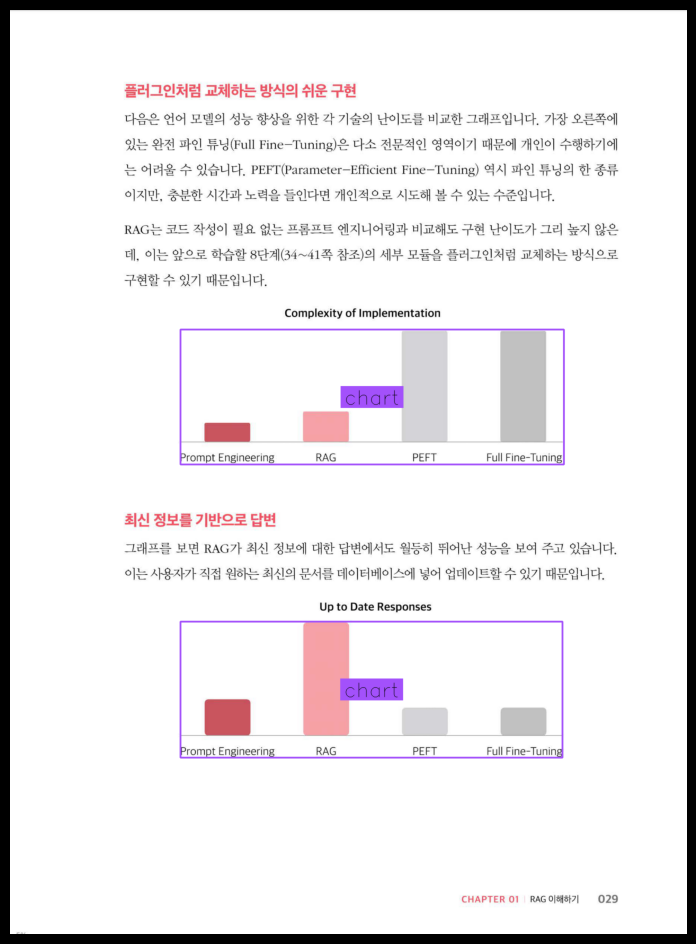

In [86]:
import supervision as sv

resolution_wh = image.size

detections = sv.Detections.from_vlm(
    vlm=sv.VLM.GOOGLE_GEMINI_2_5, result=response.text, resolution_wh=resolution_wh
)

thickness = sv.calculate_optimal_line_thickness(resolution_wh=resolution_wh)
text_scale = sv.calculate_optimal_text_scale(resolution_wh=resolution_wh)

box_annotator = sv.BoxAnnotator(thickness=thickness)
label_annotator = sv.LabelAnnotator(
    smart_position=True,
    text_color=sv.Color.BLACK,
    text_scale=text_scale,
    text_position=sv.Position.CENTER,
)
masks_annotator = sv.MaskAnnotator()

annotated = image
for annotator in (box_annotator, label_annotator, masks_annotator):
    annotated = annotator.annotate(scene=annotated, detections=detections)

sv.plot_image(annotated)

In [87]:
print(response.text)

```json
[{"box_2d": [346, 252, 492, 818], "label": "chart"}, {"box_2d": [662, 252, 809, 816], "label": "chart"}]
```
